В данной задаче 2 типа погрешностей:
1) Погрешность неустранимая, связаная с погрешностью dt ~ 10^-3
2) Погрешность метода -> разложение в ряд Маклорена

Неустранимую погрешность можно оценить как |u(b) - u(a)|, но чтобы вычислить значения функции в точке, потребуется разложить в ряд Маклорена, затем отсечь члены, начиная с n+1, и подставить нужню точку. Поэтому итоговая погрешность будет
$du = du_1 + du_2$

Для определения погрешности метода воспользуемся разложением с остаточным членом в форме Лагранжа:
$|R_{n}| = |\frac{u^{(n + 1)}(\xi)}{(n + 1)!} \cdot t^{n+1}| <= \frac{M}{(n + 1)!} \cdot |t|^{n + 1}$, где $\xi \in [0, t]$ и $M = max|u^{(n + 1)}(\xi)|$.

Но по условию существует неустранимая погрешность аргумента. Поэтому общая погрешность
$\Delta_{общ} = \Delta_{метода} + \Delta_{неустр}$
Тогда введём $safe coef$— это коэффициент, который уменьшает допустимую погрешность, чтобы учесть наличие неустранимой погрешности от других источников. Он обеспечивает запас точности, чтобы суммарная погрешность не превышала заданный предел.

In [7]:
import math

def find_min_n_sin(max_value, error_limit=1e-3, safe_coef=0.1):
    n = 0
    while True:
        term = (max_value ** (n + 1)) / math.factorial(n + 1)
        if term <= error_limit * safe_coef:
            return n
        n += 1

def find_min_n_exp(max_value, error_limit=1e-3, safe_coef=0.1):
    n = 0
    max_derivative = math.exp(max_value)
    while True:
        term = max_derivative * (max_value ** (n + 1)) / math.factorial(n + 1)
        if term <= error_limit * safe_coef:
            return n
        n += 1

result_sin = find_min_n_sin(max_value=1)
print(f"Для отрезка [0, 1] можно отбрасывать члены, начиная с n = {result_sin}")

result_exp = find_min_n_exp(max_value=1)
print(f"Для отрезка [0, 1] можно отбрасывать члены, начиная с n = {result_exp}")

Для отрезка [0, 1] можно отбрасывать члены, начиная с n = 7
Для отрезка [0, 1] можно отбрасывать члены, начиная с n = 7


Видно что на отрезке [10, 11] требуется гораздо больше членов членов разложения чтобы добиться нужно точности. Также из графика видно, что метод не сходится.
Построение графика:

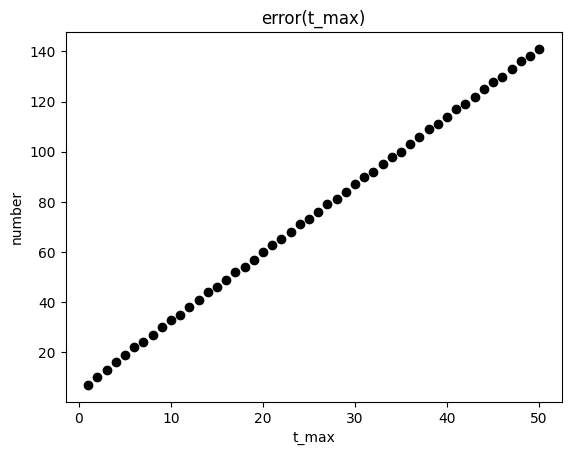

In [8]:
import matplotlib.pyplot as plt
import math

def find_n_sin(max_value, error_limit=1e-3, safe_coef=0.1):
    n = 0
    while True:
        term = (max_value ** (n + 1)) / math.factorial(n + 1)
        if term <= error_limit * safe_coef:
            return n
        n += 1

max_points = 50
x_values = [i for i in range(1, max_points + 1)]
y_values = [find_min_n_sin(value, error_limit=1e-3) for value in x_values]

plt.scatter(x_values, y_values, color='black', marker='o')
plt.xlabel('t_max')
plt.ylabel('number')
plt.title('error(t_max)')
plt.show()

Поэтому предлагается для sin(t) сдвинуть точку разложения в середину отрезка, то есть t_opt = (t_max - t_min) / 2 = 10.5.

Тогда получаем следующую оценку для ошибки метода:
$|R_{n}| = |\frac{u^{(n + 1)}(\xi)}{(n + 1)!} \cdot (t - t_{opt})^{n+1}| <= \frac{M}{(n + 1)!} \cdot |t-t_{opt}|^{n + 1}$

In [9]:
def find_min_n_sin_optimal(max_value, error_limit=1e-3, safe_coef=0.1):
    n = 0
    while True:
        term = ((max_value - 10.5) ** (n + 1)) / math.factorial(n + 1)
        if term <= error_limit * safe_coef:
            return n
        n += 1

def find_min_n_sin(max_value, error_limit=1e-3, safe_coef=0.1):
    n = 0
    while True:
        term = (max_value ** (n + 1)) / math.factorial(n + 1)
        if term <= error_limit * safe_coef:
            return n
        n += 1

result_optimal = find_min_n_sin_optimal(11, error_limit=1e-3)
result_standard = find_min_n_sin(11, error_limit=1e-3)

print(f"Для отрезка [10, 11] можно отбрасывать члены, начиная с n = {result_optimal}")
print(f"Для отрезка [10, 11] можно отбрасывать члены, начиная с n = {result_standard}")

Для отрезка [10, 11] можно отбрасывать члены, начиная с n = 5
Для отрезка [10, 11] можно отбрасывать члены, начиная с n = 35


То есть метод сходится в оптимальном случае для синуса

In [10]:
def find_min_terms_exp(max_value, error_limit=1e-3, safe_coef=0.1):
    n = 0
    max_derivative = math.exp(max_value)
    while True:
        term = max_derivative * (max_value ** (n + 1)) / math.factorial(n + 1)
        if term <= error_limit * safe_coef:
            return n
        n += 1

def find_min_terms_exp_optimal(max_value, error_limit=1e-3, safe_coef=0.1):
    n = 0
    optimal_point = 10.5
    max_derivative = math.exp(max_value)
    while True:
        term = max_derivative * ((max_value - optimal_point) ** (n + 1)) / math.factorial(n + 1)
        if term <= error_limit * safe_coef:
            return n
        n += 1

result_optimal_exp = find_min_terms_exp_optimal(11, error_limit=1e-3)
result_standard_exp = find_min_terms_exp(11, error_limit=1e-3)

print(f"Для отрезка [10, 11] можно отбрасывать члены, начиная с n = {result_optimal_exp}")
print(f"Для отрезка [10, 11] можно отбрасывать члены, начиная с n = {result_standard_exp}")

Для отрезка [10, 11] можно отбрасывать члены, начиная с n = 9
Для отрезка [10, 11] можно отбрасывать члены, начиная с n = 44


Для предложенного метода видно, что n сильно отличаются в меньшую сторону

Построим график зависимости номера, начиная с которого можно отрбрасывать члены от safe_coef

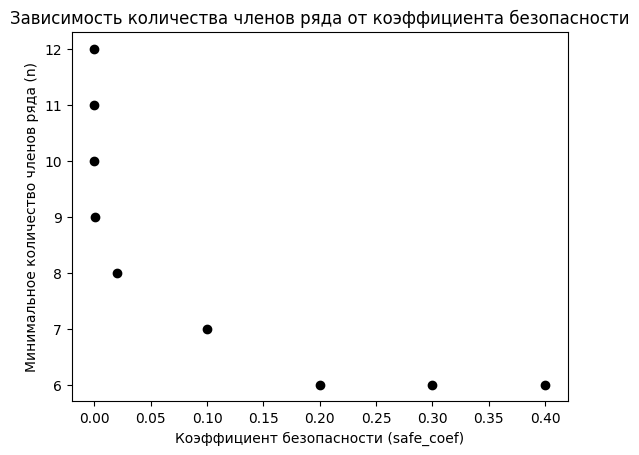

In [11]:
import matplotlib.pyplot as plt
import math

def find_min_terms_sin(max_value, error_limit=1e-3, safe_coef=0.1):
    n = 0
    while True:
        term = (max_value ** (n + 1)) / math.factorial(n + 1)
        if term <= error_limit * safe_coef:
            return n
        n += 1

safety_coefficients = [10**-1, 2 * 10**-1, 3 * 10**-1, 4 * 10**-1, 2 * 10**-2, 10**-3, 10**-4, 10**-5, 10**-6]
min_terms = []

for coef in safety_coefficients:
    min_terms.append(find_min_terms_sin(max_value=1, error_limit=1e-3, safe_coef=coef))

plt.scatter(safety_coefficients, min_terms, color='black', marker='o')
plt.xlabel('Коэффициент безопасности (safe_coef)')
plt.ylabel('Минимальное количество членов ряда (n)')
plt.title('Зависимость количества членов ряда от коэффициента безопасности')
plt.show()